# Phase 5: Handling Class Imbalance using SMOTE & Undersampling

This notebook guides you through:
1. **Loading Data**: Reading the selected features dataset.
2. **Train-Test Split**: Stratified split to keep test data clean (avoiding data leakage).
3. **Hybrid Resampling**: Oversampling minority classes using SMOTE and downsampling majority classes to a target threshold (100,000 samples) to prevent memory crashes on a 16GB RAM laptop.
4. **Visualizing Distribution**: Generating comparison plots showing class distribution before and after resampling.
5. **Data Export**: Exporting resampled train and test splits to disk for use in subsequent model training.

## 1. Imports and Paths Setup

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add the parent directory to python path to import our src modules
sys.path.append(os.path.abspath('..'))

from src.config import (
    SELECTED_FEATURES_PATH,
    X_TRAIN_RESAMPLED_PATH,
    Y_TRAIN_RESAMPLED_PATH,
    X_TEST_PATH,
    Y_TEST_PATH,
    FIGURES_DIR,
    RESAMPLE_TARGET_SAMPLES
)
from src.preprocessing import load_and_clean_data, get_train_test_data, apply_resampling

print("Libraries and path configurations loaded successfully!")

Libraries and path configurations loaded successfully!


## 2. Load and Clean Dataset
We read `selected_features.csv` and map raw labels using our standardized dictionary map (handling characters like `�` in Web Attacks).

In [2]:
df = load_and_clean_data(SELECTED_FEATURES_PATH)
print("Dataset Shape:", df.shape)
df.head()

[2026-08-02 21:08:28] INFO [preprocessing:41] - Starting execution of 'load_and_clean_data'...


[2026-08-02 21:08:28] INFO [preprocessing:15] - Loading data from A:\Network-Intrusion-Detection-System\dataset\cleaned\selected_features.csv...


[2026-08-02 21:08:37] INFO [preprocessing:29] - Cleaning label names...


[2026-08-02 21:08:37] INFO [preprocessing:38] - Loaded dataset with shape (2522362, 31)


[2026-08-02 21:08:37] INFO [preprocessing:53] - Finished 'load_and_clean_data' in 9.18s


Dataset Shape: (2522362, 31)


,Fwd IAT Std,Bwd IAT Min,Flow IAT Min,Bwd Packet Length Std,Bwd Packet Length Mean,Avg Bwd Segment Size,Idle Min,Bwd Packet Length Max,Idle Mean,Packet Length Std,...,PSH Flag Count,Active Mean,Fwd IAT Total,ACK Flag Count,Flow Duration,Bwd IAT Std,Subflow Fwd Bytes,Flow IAT Mean,Min Packet Length,Label
0,0.0,0,3,0.0,0.0,0.0,0,0,0.0,0.0,...,0,0.0,3,1,3,0.0,12,3.0,6,BENIGN
1,0.0,0,109,0.0,6.0,6.0,0,6,0.0,0.0,...,0,0.0,0,1,109,0.0,6,109.0,6,BENIGN
2,0.0,0,52,0.0,6.0,6.0,0,6,0.0,0.0,...,0,0.0,0,1,52,0.0,6,52.0,6,BENIGN
3,0.0,0,34,0.0,6.0,6.0,0,6,0.0,0.0,...,0,0.0,0,1,34,0.0,6,34.0,6,BENIGN
4,0.0,0,3,0.0,0.0,0.0,0,0,0.0,0.0,...,0,0.0,3,1,3,0.0,12,3.0,6,BENIGN


## 3. Train-Test Split
We execute a stratified 80% train and 20% test split to make sure the target distributions are split proportionally.

In [3]:
X_train, X_test, y_train, y_test = get_train_test_data(df)

# Keep track of class counts before resampling
original_counts = y_train.value_counts()
print("Original Training Class counts:\n", original_counts)

[2026-08-02 21:08:37] INFO [preprocessing:41] - Starting execution of 'get_train_test_data'...


[2026-08-02 21:08:37] INFO [preprocessing:44] - Splitting dataset with test size 0.2 and stratify...


[2026-08-02 21:08:41] INFO [preprocessing:55] - Train set shape: (2017889, 30), Test set shape: (504473, 30)


[2026-08-02 21:08:41] INFO [preprocessing:53] - Finished 'get_train_test_data' in 3.52s


Original Training Class counts:
 Label
BENIGN                        1677187
DoS Hulk                       138279
DDoS                           102413
PortScan                        72655
DoS GoldenEye                    8229
FTP-Patator                      4746
DoS slowloris                    4308
DoS Slowhttptest                 4182
SSH-Patator                      2575
Bot                              1562
Web Attack - Brute Force         1176
Web Attack - XSS                  522
Infiltration                       29
Web Attack - SQL Injection         17
Heartbleed                          9
Name: count, dtype: int64


## 4. Execute Resampling (SMOTE + Downsampling)
We oversample minority classes with SMOTE and downsample majority classes down to `RESAMPLE_TARGET_SAMPLES` (100,000 samples) to ensure the dataset is perfectly balanced without overloading your laptop's memory.

In [4]:
X_train_res, y_train_res = apply_resampling(X_train, y_train, target_samples=RESAMPLE_TARGET_SAMPLES)
resampled_counts = y_train_res.value_counts()
print("Resampled Training Class counts:\n", resampled_counts)

[2026-08-02 21:08:41] INFO [preprocessing:41] - Starting execution of 'apply_resampling'...


[2026-08-02 21:08:41] INFO [preprocessing:66] - Applying hybrid resampling. Target samples per class: 100000


[2026-08-02 21:08:41] INFO [preprocessing:70] - Original training class distribution:
Label
BENIGN                        1677187
DoS Hulk                       138279
DDoS                           102413
PortScan                        72655
DoS GoldenEye                    8229
FTP-Patator                      4746
DoS slowloris                    4308
DoS Slowhttptest                 4182
SSH-Patator                      2575
Bot                              1562
Web Attack - Brute Force         1176
Web Attack - XSS                  522
Infiltration                       29
Web Attack - SQL Injection         17
Heartbleed                          9
Name: count, dtype: int64


[2026-08-02 21:08:41] INFO [preprocessing:82] - Classes to oversample: ['PortScan', 'DoS GoldenEye', 'FTP-Patator', 'DoS slowloris', 'DoS Slowhttptest', 'SSH-Patator', 'Bot', 'Web Attack - Brute Force', 'Web Attack - XSS', 'Infiltration', 'Web Attack - SQL Injection', 'Heartbleed']


[2026-08-02 21:08:41] INFO [preprocessing:90] - Running SMOTE with k_neighbors=5...


...

[2026-08-02 21:08:56] INFO [preprocessing:115] - Running RandomUnderSampler...


[2026-08-02 21:09:07] INFO [preprocessing:121] - After Undersampling, training set shape: (1500000, 30)


[2026-08-02 21:09:07] INFO [preprocessing:125] - Balanced training class distribution:
Label
BENIGN                        100000
Bot                           100000
DDoS                          100000
DoS GoldenEye                 100000
DoS Hulk                      100000
DoS Slowhttptest              100000
DoS slowloris                 100000
FTP-Patator                   100000
Heartbleed                    100000
Infiltration                  100000
PortScan                      100000
SSH-Patator                   100000
Web Attack - Brute Force      100000
Web Attack - SQL Injection    100000
Web Attack - XSS              100000
Name: count, dtype: int64


[2026-08-02 21:09:07] INFO [preprocessing:53] - Finished 'apply_resampling' in 25.65s


Resampled Training Class counts:
 Label
BENIGN                        100000
Bot                           100000
DDoS                          100000
DoS GoldenEye                 100000
DoS Hulk                      100000
DoS Slowhttptest              100000
DoS slowloris                 100000
FTP-Patator                   100000
Heartbleed                    100000
Infiltration                  100000
PortScan                      100000
SSH-Patator                   100000
Web Attack - Brute Force      100000
Web Attack - SQL Injection    100000
Web Attack - XSS              100000
Name: count, dtype: int64


## 5. Visualize Class Distributions Before and After
Let's plot the comparison between the original training class distribution and the balanced class distribution side-by-side.

C:\Users\sabar\AppData\Local\Temp\ipykernel_8956\1859585489.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=original_counts.values, y=original_counts.index, ax=axes[0], palette="viridis")


C:\Users\sabar\AppData\Local\Temp\ipykernel_8956\1859585489.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=resampled_counts.values, y=resampled_counts.index, ax=axes[1], palette="viridis")


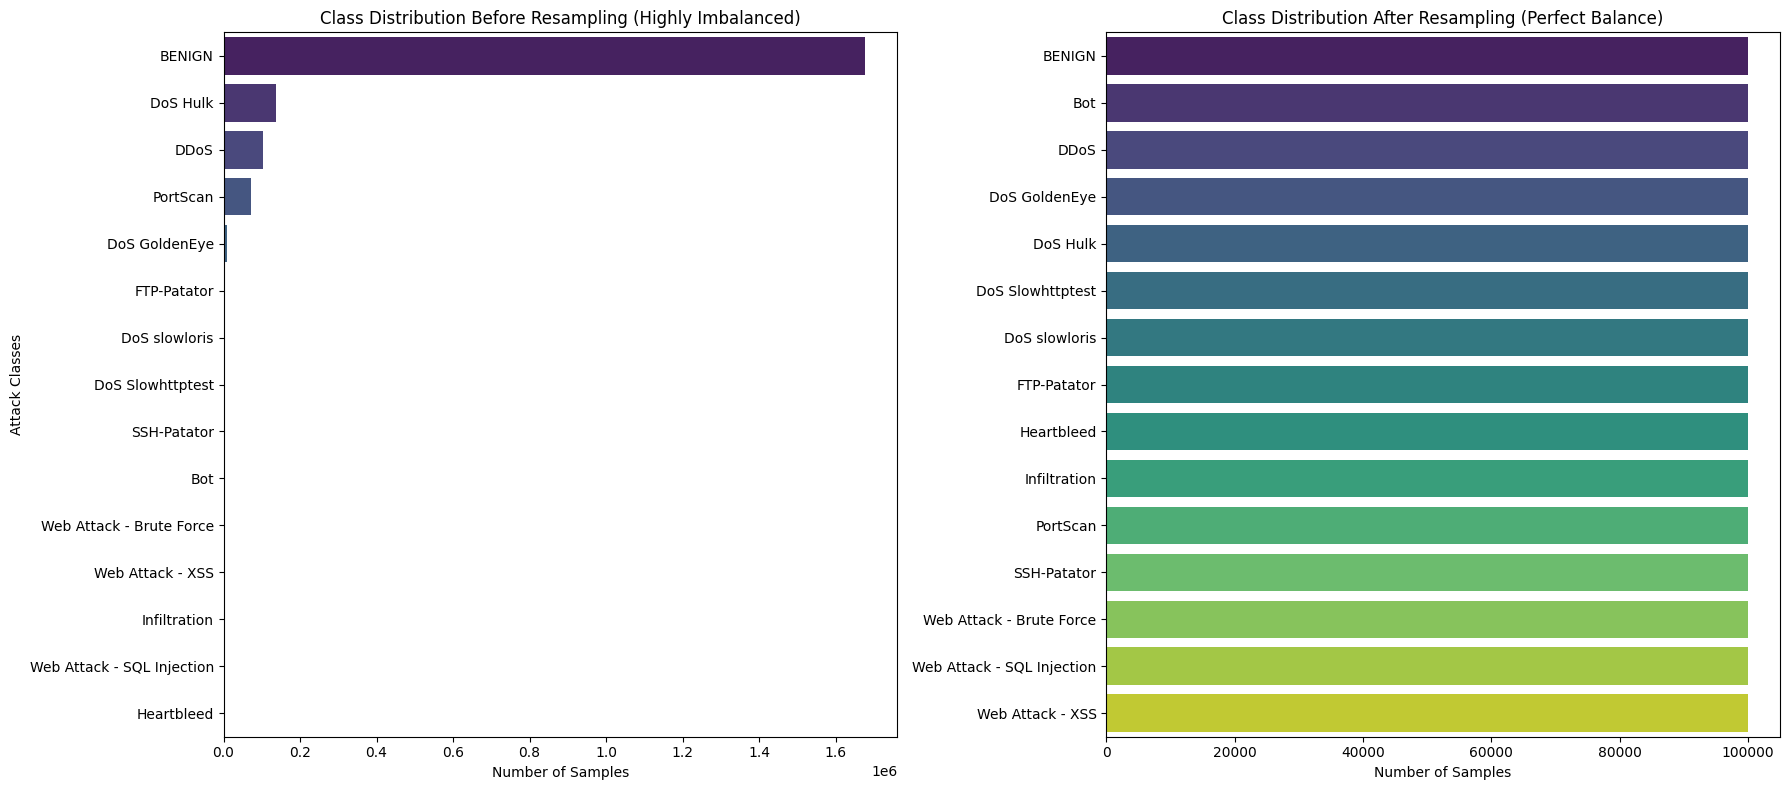

Distribution comparison plot saved to A:\Network-Intrusion-Detection-System\results\figures\class_distribution_comparison.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=False)

# Plot Original
sns.barplot(x=original_counts.values, y=original_counts.index, ax=axes[0], palette="viridis")
axes[0].set_title("Class Distribution Before Resampling (Highly Imbalanced)")
axes[0].set_xlabel("Number of Samples")
axes[0].set_ylabel("Attack Classes")

# Plot Resampled
sns.barplot(x=resampled_counts.values, y=resampled_counts.index, ax=axes[1], palette="viridis")
axes[1].set_title("Class Distribution After Resampling (Perfect Balance)")
axes[1].set_xlabel("Number of Samples")
axes[1].set_ylabel("")

plt.tight_layout()
fig_path = FIGURES_DIR / "class_distribution_comparison.png"
plt.savefig(fig_path, dpi=300)
plt.show()
print(f"Distribution comparison plot saved to {fig_path}")

## 6. Save Splitted and Resampled Data to Disk
We export these processed matrices into CSV files so they can be loaded instantly in the training notebook.

In [6]:
print("Saving resampled training features to:", X_TRAIN_RESAMPLED_PATH)
X_train_res.to_csv(X_TRAIN_RESAMPLED_PATH, index=False)

print("Saving resampled training labels to:", Y_TRAIN_RESAMPLED_PATH)
y_train_res.to_csv(Y_TRAIN_RESAMPLED_PATH, index=False)

print("Saving test features to:", X_TEST_PATH)
X_test.to_csv(X_TEST_PATH, index=False)

print("Saving test labels to:", Y_TEST_PATH)
y_test.to_csv(Y_TEST_PATH, index=False)

print("Data export finished successfully!")

Saving resampled training features to: A:\Network-Intrusion-Detection-System\dataset\cleaned\X_train_resampled.csv


Saving resampled training labels to: A:\Network-Intrusion-Detection-System\dataset\cleaned\y_train_resampled.csv


Saving test features to: A:\Network-Intrusion-Detection-System\dataset\cleaned\X_test.csv


Saving test labels to: A:\Network-Intrusion-Detection-System\dataset\cleaned\y_test.csv


Data export finished successfully!
